# Two, three and four aircraft on a ring: Monte Carlo against IPS

Put `N` drones on a circle, point each one at the opposite side, and every aircraft conflicts with
every other one at the same instant. That is the
[circle scenario](circle_scenario.ipynb), and with a competent separation manager flying it, a loss
of separation is *rare* — rare enough that counting failures stops working as a way of measuring
them.

This notebook runs the same three fleets — `N` = 2, 3 and 4 — through **two estimators of the same
probability**:

- **plain Monte Carlo** (`run_fleet` over independent noise draws), which counts how often
  separation is lost, and
- the **interacting particle system** (`opencdarr.ips`), which splits a fixed particle population
  through a ladder of shrinking separation shells and returns the probability with a confidence
  interval.

Everything else is held: `StateBased` detection, `MVP` resolution, `ProbabilisticFTR` recovery, and
a GNSS fix declared and drawn at **10 m / 1 m/s** (95%). The separation algorithms never learn which
estimator is driving them — that equivalence is the point of the estimator interface, and it is
what makes the two results comparable rather than merely adjacent.

It runs the comparison twice, on two kinds of traffic. **Part 1** is the ring: one arranged worst
case, `N` = 2, 3 and 4, every aircraft in conflict with every other at the same instant. **Part 2**
is random traffic drawn by the entry rule of Groot, Ellerbroek and Hoekstra (2024) — `N` = 4, 6 and
8 drones crossing a 1 km disc on random headings, spawned outside it and measured inside. The first
asks what happens in the worst arrangement; the second asks what happens on average over the
arrangements that occur.

> **Why this drives the estimators directly rather than `run_experiment`.** The declarative sweep in
> `opencdarr.experiment` builds its encounters with `sample_pairwise`, so both of its backends are
> two-aircraft. A ring of three or four aircraft has to be built as a fleet, which means calling
> `run_fleet` and `estimate_rare_prob` yourself. They are the same two estimators `run_experiment`
> would have called.

In [1]:
%matplotlib inline
import dataclasses
import math
import time

import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed

plt.rcParams["figure.dpi"] = 130

from opencdarr import (
    M600,
    MVP,
    Agent,
    GnssNavigation,
    MeasurementArea,
    StateBased,
    crossing_ring,
    random_traffic,
    run_fleet,
)
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.crr import ProbabilisticFTR
from opencdarr.estimator import wilson_interval
from opencdarr.fleet import CnsStreams, FleetStreams, build_env
from opencdarr.geo import qdrdist
from opencdarr.ips import Particle
from opencdarr.mission import Mission
from opencdarr.parallel import estimate_rare_prob
from opencdarr.rng import children, generator, root_seed_sequence
from opencdarr.viz import extract_tracks

CENTRE = (52.0, 4.0)   # ring centre (lat, lon)
RADIUS = 500.0         # ring radius [m]
SPEED = 10.0           # cruise speed [m/s]
RPZ = 50.0             # protected zone radius [m]
LOOKAHEAD = 30.0       # detection horizon [s]
DT = 0.5               # integration step [s]
MARGIN = 1.05          # MVP's resolution margin

POS_CI95, VEL_CI95 = 10.0, 1.0   # the GNSS fix, 95% -- declared and drawn
SIZES = (2, 3, 4)                # fleet sizes

PERF = dataclasses.replace(M600, v_max=SPEED, v_min=-SPEED)   # so "speed" is really the speed

# Part 1: the ring

## The scenario

Aircraft `i` starts at bearing `360 i / N` from the centre and flies to the point diametrically
opposite, which puts its whole route on a diameter and every route through the same point. Each one
carries a `WaypointAutopilot`, so after being pushed off course it turns back toward its
destination rather than drifting away.

`RULES` is the one place the separation stack is named — detection, resolution, recovery, the
protected zone and the horizon. Both estimators below build their environment from that same
bundle, which is what keeps the comparison a comparison of estimators.

In [2]:
def ring(n, pos_ci95=0.0, vel_ci95=0.0):
    """n multirotors on the ring, each aimed at the point diametrically opposite."""
    return [
        Agent(state, PERF, autopilot=WaypointAutopilot(Mission(goto=goal), capture_radius=30.0))
        for state, goal in crossing_ring(n, speed=SPEED, radius=RADIUS,
                                         lat0=CENTRE[0], lon0=CENTRE[1],
                                         pos_ci95=pos_ci95, vel_ci95=vel_ci95)
    ]


# The fixed rules -- one bundle, used by run_fleet (Monte Carlo) and build_env (IPS) alike.
RULES = dict(
    rpz=RPZ, t_lookahead=LOOKAHEAD, dt=DT,
    detector=StateBased(), resolver=MVP(MARGIN), recovery=ProbabilisticFTR(),
    t_max=600.0, done_timeout=10.0, stop_within=50.0,
)

First fly each fleet with the noise switched off. The aircraft still *declare* a 10 m fix — that is
what `ProbabilisticFTR` sizes its uncertainty from, so declaring nothing would quietly be a
different recovery rule — but no error is drawn, because no `navigation` model is passed. This is
the geometry the noise then has to eat through:

In [3]:
clean = {n: run_fleet(ring(n, POS_CI95, VEL_CI95), record=True, **RULES) for n in SIZES}

for n in SIZES:
    r = clean[n]
    print(f"N = {n}   closest approach {r.min_sep:6.1f} m   "
          f"separation lost: {str(r.los):>5}   finished at {r.frames[-1].t:.0f} s")

N = 2   closest approach   70.5 m   separation lost: False   finished at 60 s
N = 3   closest approach   96.8 m   separation lost: False   finished at 62 s
N = 4   closest approach   52.6 m   separation lost: False   finished at 66 s


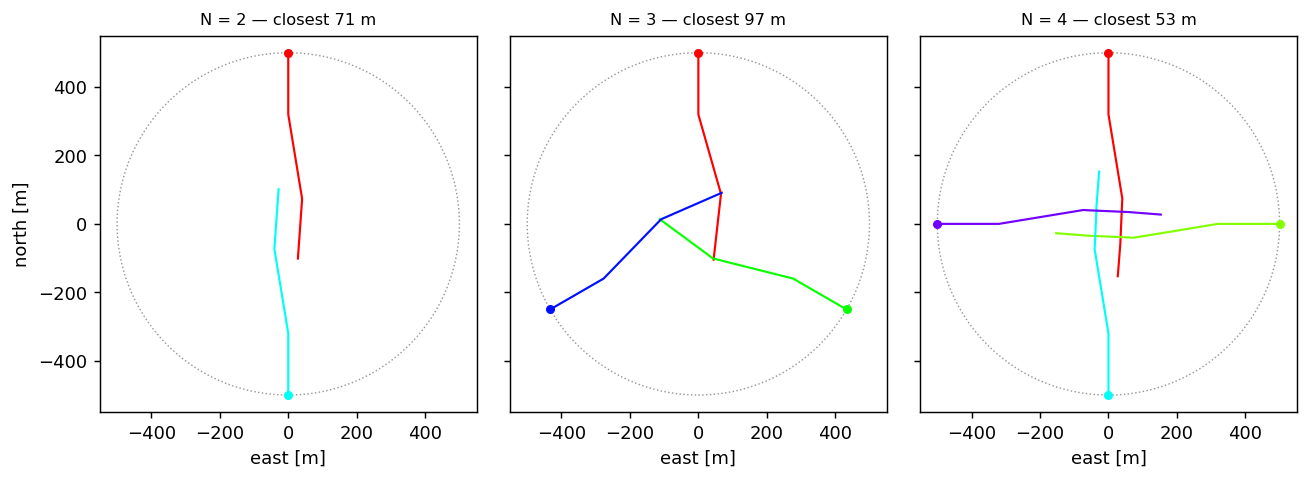

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.7), sharex=True, sharey=True)
for ax, n in zip(axes, SIZES, strict=True):
    paths = extract_tracks(clean[n]).tracks          # east/north [m], origin at D0's start
    hub = np.mean([xy[0] for xy in paths], axis=0)   # the ring centre in that frame
    for k, xy in enumerate(paths):
        colour = plt.cm.hsv(k / n)
        ax.plot(xy[:, 0] - hub[0], xy[:, 1] - hub[1], lw=1.2, color=colour)
        ax.plot(xy[0, 0] - hub[0], xy[0, 1] - hub[1], "o", ms=4, color=colour)
    ax.add_patch(plt.Circle((0, 0), RADIUS, fill=False, ls=":", lw=0.8, color="0.6"))
    ax.set_aspect("equal")
    ax.set_title(f"N = {n} — closest {clean[n].min_sep:.0f} m", fontsize=9)
    ax.set_xlabel("east [m]")
axes[0].set_ylabel("north [m]")
fig.tight_layout()

Dots are the starts, the dotted circle is the ring. Three different shapes come out of one rule:
the pair passes side by side, the triangle rotates around an empty centre, and the two crossing
diameters of `N = 4` fold into the tightest picture of the three. The closest approaches say the
same thing — the four-aircraft fleet lands almost exactly on the 52.5 m that `MVP` was asked for,
with nothing spare, while the pair and the triangle end up well above it.

## Estimator 1: Monte Carlo

Now give every aircraft a GNSS fix that is wrong by about 10 m, and run the same ring over
independent noise draws. The geometry is identical every time; only what each aircraft *believes*
changes. One encounter is one seeded draw, and the estimate is the fraction of them that lost
separation.

In [5]:
MC_ENCOUNTERS = 2000     # per fleet size


def one_encounter(n, seq):
    run = run_fleet(ring(n, POS_CI95, VEL_CI95), navigation=GnssNavigation(),
                    rng=generator(seq), **RULES)
    return run.los, run.min_sep


mc = {}
t0 = time.perf_counter()
for n in SIZES:
    seqs = children(root_seed_sequence(0), 0, MC_ENCOUNTERS)
    out = Parallel(n_jobs=-1, batch_size=32)(delayed(one_encounter)(n, s) for s in seqs)
    mc[n] = dict(los=np.array([o[0] for o in out]),
                 min_sep=np.array([o[1] for o in out], dtype=float))
print(f"{len(SIZES) * MC_ENCOUNTERS} encounters in {time.perf_counter() - t0:.0f} s")

for n in SIZES:
    k = int(mc[n]["los"].sum())
    lo, hi = wilson_interval(k, MC_ENCOUNTERS)
    print(f"N = {n}   {k:>2}/{MC_ENCOUNTERS} lost separation   "
          f"P(LoS) = {k / MC_ENCOUNTERS:.2e}   95% Wilson [{lo:.1e}, {hi:.1e}]")

6000 encounters in 45 s
N = 2    0/2000 lost separation   P(LoS) = 0.00e+00   95% Wilson [1.1e-19, 1.9e-03]
N = 3    1/2000 lost separation   P(LoS) = 5.00e-04   95% Wilson [8.8e-05, 2.8e-03]
N = 4    2/2000 lost separation   P(LoS) = 1.00e-03   95% Wilson [2.7e-04, 3.6e-03]


The top row reads **zero**, and a zero is not a small number — it is an absence of measurement. The
Wilson interval is the honest reading: after two thousand encounters all we can say about the pair
is that `P(LoS)` is somewhere below a few times `10⁻³`, which is a statement about the sample size
rather than about the fleet.

The other two rows are barely better off. They rest on one event and two events, and an estimate
built on two events has an interval more than a decade wide — the counts are large enough to prove
the failures exist and too small to say how often. Tightening that by counting means running on the
order of `1/P` encounters, and `P` is the thing we do not know.

What the same runs do measure well is where the separations pile up:

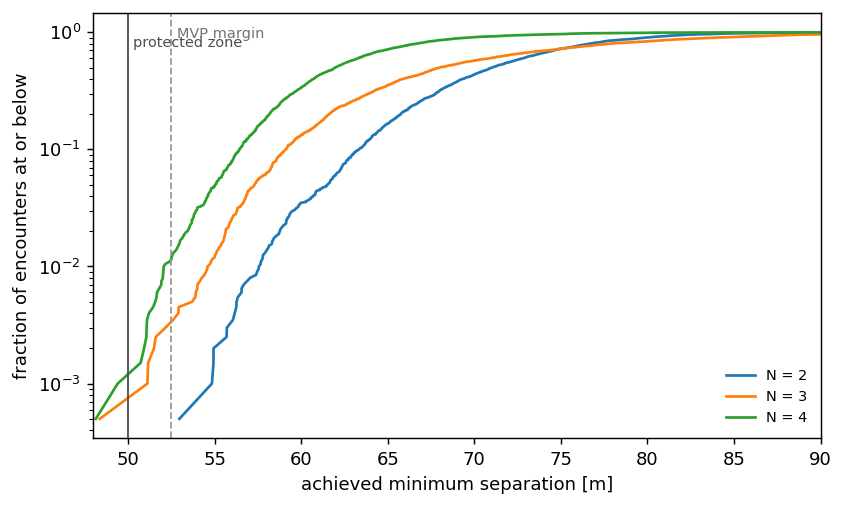

In [6]:
fig, ax = plt.subplots(figsize=(6.6, 4.0))
for n in SIZES:
    s = np.sort(mc[n]["min_sep"])
    ax.plot(s, np.arange(1, s.size + 1) / s.size, lw=1.5, label=f"N = {n}")
ax.axvline(RPZ, color="0.3", lw=1.0)
ax.axvline(RPZ * MARGIN, color="0.6", lw=1.0, ls="--")
ax.annotate("protected zone", (RPZ, 0.75), xytext=(3, 0), textcoords="offset points",
            fontsize=8, color="0.3")
ax.annotate("MVP margin", (RPZ * MARGIN, 0.9), xytext=(3, 0), textcoords="offset points",
            fontsize=8, color="0.45")
ax.set_xlim(RPZ - 2, 90)
ax.set_yscale("log")
ax.set_xlabel("achieved minimum separation [m]")
ax.set_ylabel("fraction of encounters at or below")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

The lower tail of each distribution runs into a wall a little above 50 m, and the wall sits where
`MVP` was told to put it: the resolver aims at `rpz × margin` = 52.5 m, so that is the separation the
fleet is actively driven back to. Crossing it is not a matter of drifting slightly further — the
resolver has to be beaten, which takes a large perception error sustained long enough to matter.
That is the barrier the rare-event estimator has to push a particle population through, and it is
why the ladder below is fine-grained exactly there.

## The ladder

IPS needs a decreasing sequence of shells on the running minimum separation, ending at `rpz`. Each
shell should keep a healthy fraction of the particles that reached the one above — roughly 10–50%.
Too coarse and a level collapses to no survivors; too fine and the effort is wasted re-crossing
shells everything reaches.

The Monte Carlo above already measured the distribution the shells should follow, so the ladder is
built from it: while the sample can still resolve a quantile, put the next shell where half the
survivors are expected to reach it. Below the sample's floor there is no data left, and the ladder
falls back to a uniform half-metre step — which is the region through MVP's margin, where the
descent has to be slow anyway.

In [7]:
def build_ladder(min_seps, rpz=RPZ, *, halving=0.5, min_count=30, step=0.5):
    """Shells from the Monte Carlo record, then a fixed-step run-in below its floor."""
    ms = np.asarray(min_seps, dtype=float)
    shells, p, floor = [], halving, min_count / ms.size
    while p >= floor:                                    # quantile shells, while resolvable
        d = float(np.percentile(ms, p * 100))
        if d > rpz and (not shells or d < shells[-1] - step):
            shells.append(d)
        p *= halving
    d = (shells[-1] if shells else float(ms.max())) - step
    while d > rpz:                                       # uniform run-in through the margin
        shells.append(d)
        d -= step
    shells.append(rpz)
    return [round(x, 2) for x in shells]


LADDERS = {n: build_ladder(mc[n]["min_sep"]) for n in SIZES}
for n in SIZES:
    print(f"N = {n}  ({len(LADDERS[n])} shells)  " + "  ".join(f"{d:g}" for d in LADDERS[n]))

N = 2  (23 shells)  71.03  66.75  64.03  62.07  59.75  58.32  57.82  57.32  56.82  56.32  55.82  55.32  54.82  54.32  53.82  53.32  52.82  52.32  51.82  51.32  50.82  50.32  50
N = 3  (17 shells)  68  62.8  59.78  58  56.34  55.45  54.95  54.45  53.95  53.45  52.95  52.45  51.95  51.45  50.95  50.45  50
N = 4  (12 shells)  61.95  58.81  56.95  55.5  54  52.99  52.49  51.99  51.49  50.99  50.49  50


## Estimator 2: IPS

A particle is one aircraft-fleet plus the rules it flies under. The geometry here is fixed — the
ring is the same every time, and the randomness is entirely in the CNS noise — so every particle
starts from one shared initial state, and the seed handed to `build_initial` feeds the forward noise
instead. `FleetEnv` and `FleetState` are deeply immutable, so sharing one is safe and keeps the
cloud cheap to hand to worker processes.

Within a replication the particles interact through shared ancestors, so the confidence interval
comes from independent replications rather than from the spread inside one.

The particle count is set per fleet size rather than shared. The `N = 2` cell is the rarest and has
the longest ladder, which is exactly the combination that thins a population out: by the bottom
shells the survivors can all descend from one lucky ancestor, and a run that arrives there with too
few of them either collapses or reports whatever that one lineage did.

In [8]:
N_PARTICLES = {2: 2500, 3: 1500, 4: 1000}   # per shell -- the rarer the cell, the more it needs
REPS = 6                                    # independent replications -> the interval


def start_particle(n):
    """The one starting world: the ring, its rules, and the CNS stack that will perturb it."""
    agents = ring(n, POS_CI95, VEL_CI95)
    env = build_env(agents, navigation=GnssNavigation(), **RULES)
    return Particle(env=env, state=env.initial_state(agents))


def fixed_cloud(particle):
    """Hand every particle the same starting world, so the seed feeds the noise, not the setup."""
    def build_initial(seq):
        return particle
    return build_initial


ips = {}
for n in SIZES:
    t0 = time.perf_counter()
    ips[n] = estimate_rare_prob(fixed_cloud(start_particle(n)), LADDERS[n],
                                n_particles=N_PARTICLES[n], reps=REPS, seed=1, n_jobs=-1)
    est = ips[n]
    print(f"N = {n}   P(LoS) = {est.prob:.2e}   95% CI [{est.ci[0]:.1e}, {est.ci[1]:.1e}]   "
          f"collapsed {est.n_collapsed}/{REPS}   "
          f"({N_PARTICLES[n]} particles, {time.perf_counter() - t0:.0f} s)")

N = 2   P(LoS) = 4.65e-05   95% CI [2.2e-07, 9.2e-05]   collapsed 0/6   (2500 particles, 841 s)


N = 3   P(LoS) = 3.37e-04   95% CI [6.6e-05, 6.2e-04]   collapsed 0/6   (1500 particles, 549 s)


N = 4   P(LoS) = 1.81e-03   95% CI [7.8e-04, 2.7e-03]   collapsed 0/6   (1000 particles, 525 s)


**Watch the collapse count.** A replication collapses when some shell ends with no survivors; it
returns `P̂ = 0`, and it is a failed run rather than a data point — the product estimator is
unbiased only if collapses are counted rather than dropped. A non-zero count means the ladder is too
aggressive for this rarity, and the fix is a finer ladder or more particles, not a re-seed.

The per-shell survival fractions are the diagnostic behind each estimate:

In [9]:
for n in SIZES:
    good = [r for r in ips[n].reps if r.collapsed_at is None]
    if not good:
        print(f"N = {n}: every replication collapsed")
        continue
    mean = [sum(r.survival[k] for r in good) / len(good) for k in range(len(LADDERS[n]))]
    print(f"N = {n}")
    for d, s in zip(LADDERS[n], mean, strict=True):
        print(f"   {d:6.2f} m  {s:.2f}  " + "#" * round(s * 40))

N = 2
    71.03 m  0.50  ####################
    66.75 m  0.49  ###################
    64.03 m  0.48  ###################
    62.07 m  0.52  #####################
    59.75 m  0.42  #################
    58.32 m  0.52  #####################
    57.82 m  0.78  ###############################
    57.32 m  0.77  ###############################
    56.82 m  0.75  ##############################
    56.32 m  0.77  ###############################
    55.82 m  0.77  ###############################
    55.32 m  0.78  ###############################
    54.82 m  0.71  #############################
    54.32 m  0.76  ##############################
    53.82 m  0.58  #######################
    53.32 m  0.74  #############################
    52.82 m  0.70  ############################
    52.32 m  0.53  #####################
    51.82 m  0.54  #####################
    51.32 m  0.55  ######################
    50.82 m  0.54  ######################
    50.32 m  0.48  ###################
    50.0

## The two estimates side by side

The two fleets where Monte Carlo saw anything at all are the rows where the estimators can be
compared directly, and that comparison is the check that matters: agreement where Monte Carlo is
trustworthy is what licenses the IPS numbers where it is not.

In [10]:
def interval(lo, hi):
    # a Wilson lower bound at zero events comes back as round-off rather than a clean 0
    return f"[{0.0 if lo < 1e-12 else lo:8.2e}, {hi:8.2e}]"


print(f"{'N':>3}  {'MC P(LoS)':>22}  {'MC 95% CI':>22}   {'IPS P(LoS)':>11}  {'IPS 95% CI':>22}")
for n in SIZES:
    k = int(mc[n]["los"].sum())
    p_mc = "no events" if k == 0 else f"{k / MC_ENCOUNTERS:.2e} ({k} event{'s' * (k > 1)})"
    est = ips[n]
    print(f"{n:>3}  {p_mc:>22}  {interval(*wilson_interval(k, MC_ENCOUNTERS))}   "
          f"{est.prob:>11.2e}  {interval(*est.ci)}")

  N               MC P(LoS)               MC 95% CI    IPS P(LoS)              IPS 95% CI
  2               no events  [0.00e+00, 1.92e-03]      4.65e-05  [2.24e-07, 9.20e-05]
  3      5.00e-04 (1 event)  [8.83e-05, 2.83e-03]      3.37e-04  [6.56e-05, 6.21e-04]
  4     1.00e-03 (2 events)  [2.74e-04, 3.64e-03]      1.81e-03  [7.75e-04, 2.68e-03]


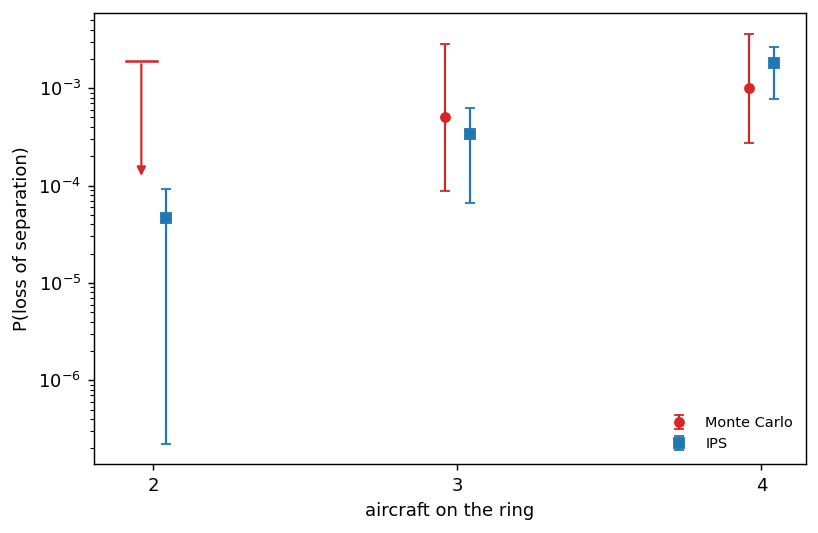

In [11]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
x = np.array(SIZES, dtype=float)

mc_p = np.array([mc[n]["los"].sum() / MC_ENCOUNTERS for n in SIZES])
mc_ci = np.array([wilson_interval(int(mc[n]["los"].sum()), MC_ENCOUNTERS) for n in SIZES])
seen = mc_p > 0
ax.errorbar(x[seen] - 0.04, mc_p[seen],
            yerr=[mc_p[seen] - mc_ci[seen, 0], mc_ci[seen, 1] - mc_p[seen]],
            fmt="o", ms=5, capsize=3, lw=1.2, color="#d62728", label="Monte Carlo")
for xi, hi in zip(x[~seen] - 0.04, mc_ci[~seen, 1], strict=True):
    ax.annotate("", (xi, hi * 0.06), (xi, hi), arrowprops=dict(arrowstyle="-|>", lw=1.2,
                                                              color="#d62728"))
    ax.plot([xi - 0.05, xi + 0.05], [hi, hi], lw=1.4, color="#d62728")

ips_p = np.array([ips[n].prob for n in SIZES])
ips_ci = np.array([ips[n].ci for n in SIZES])
ax.errorbar(x + 0.04, ips_p, yerr=[ips_p - ips_ci[:, 0], ips_ci[:, 1] - ips_p],
            fmt="s", ms=5, capsize=3, lw=1.2, color="#1f77b4", label="IPS")

ax.set_yscale("log")
ax.set_xticks(list(SIZES))
ax.set_xlabel("aircraft on the ring")
ax.set_ylabel("P(loss of separation)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

Red is Monte Carlo, blue is IPS. Where Monte Carlo saw no event, the bar with the downward arrow is
its 95% upper bound — everything it is entitled to say. Where it did see events, the two intervals
overlap, which is the agreement the rare-event estimate rests on.

The trend is the substantive result: the risk climbs steeply with the number of aircraft on the
ring. It is the same separation logic, the same protected zone and the same fix accuracy in all
three fleets; what changes is that avoiding two intruders at once leaves less room than avoiding
one, and `MVP` sums the pushes rather than solving them jointly. Monte Carlo can see the top of that
trend and nothing else; the ladder is what reaches the rest of it.

# Part 2: random traffic

The ring is a worst case by construction — everything conflicts with everything at one instant, and
the answer it gives is about that instant. The natural counterpart is traffic whose geometry is
*drawn* rather than arranged, and there is a published rule for drawing it: Groot, Ellerbroek and
Hoekstra (2024), the same entry-bearing construction the
[traffic density notebook](traffic_density.ipynb) uses.

**The entry rule.** Draw a heading `ψ` uniformly on [0°, 360°), and place the aircraft's track at a
perpendicular offset `R·x` from the centre with `x ~ U[-1, 1]`. Written as a bearing from the
centre that is the paper's Eq. (8), `entry bearing = ψ + 180° + asin(x)`. The `asin` is the whole
point: spreading entry *bearings* uniformly around the perimeter would crowd the traffic toward the
edges of the disc, while spreading the *offset* uniformly across the diameter makes it homogeneous
across the area being measured. The mission then follows from the geometry rather than being chosen
— the aircraft flies the chord its track cuts, of length `2√(R² - offset²)`, which is a diameter
only when the offset is zero.

**Two circles, not one.** Aircraft are spawned on an outer circle at 1.2 km and separation is
measured only inside the 1 km disc (the paper's 1.62/1.35 NM pair, same ratio). That split is doing
real work here. The paper creates aircraft one at a time on an interval set by the traffic density,
so two never appear at the same place at once; spawning `N` drones *simultaneously* on a circle is
a different proposition, and near-coincident starts are common rather than rare — on a 1 km circle
the expected number of pairs starting within 200 m of each other is about 0.4 at `N = 4` and 1.8 at
`N = 8`. A pair that materialises 150 m apart and converging has had no opportunity to be separated
earlier, so any loss it produces measures the spawn, not the separation logic. Entering 200 m
outside the measurement area gives every aircraft about 20 s of flight before it counts.

**One deviation from the paper, stated.** Eq. (8) references the offset to the *outer* radius, so
about 17% of aircraft graze past the inner disc and never enter it — which is fine when the
controlled quantity is a density, and awkward when it is a count of four, six or eight. Here the
offset is drawn across the *inner* diameter and the entry point is projected back out to the outer
circle along the heading, so all `N` aircraft cross the measured disc and the traffic is
homogeneous across it.

In [12]:
R_INNER = 1000.0   # the experimental disc -- where separation is measured
R_OUTER = 1200.0   # the spawn circle, giving ~200 m of run-in before anything counts
RSIZES = (4, 6, 8)


def sample_traffic(n, rng):
    """n drones crossing the measured disc, entry offsets uniform across its diameter."""
    return [
        Agent(state, PERF, autopilot=WaypointAutopilot(Mission(goto=goal), capture_radius=30.0))
        for state, goal in random_traffic(n, rng, speed=SPEED, r_inner=R_INNER, r_outer=R_OUTER,
                                          lat0=CENTRE[0], lon0=CENTRE[1],
                                          pos_ci95=POS_CI95, vel_ci95=VEL_CI95)
    ]

One draw at each fleet size, to see what the rule produces:

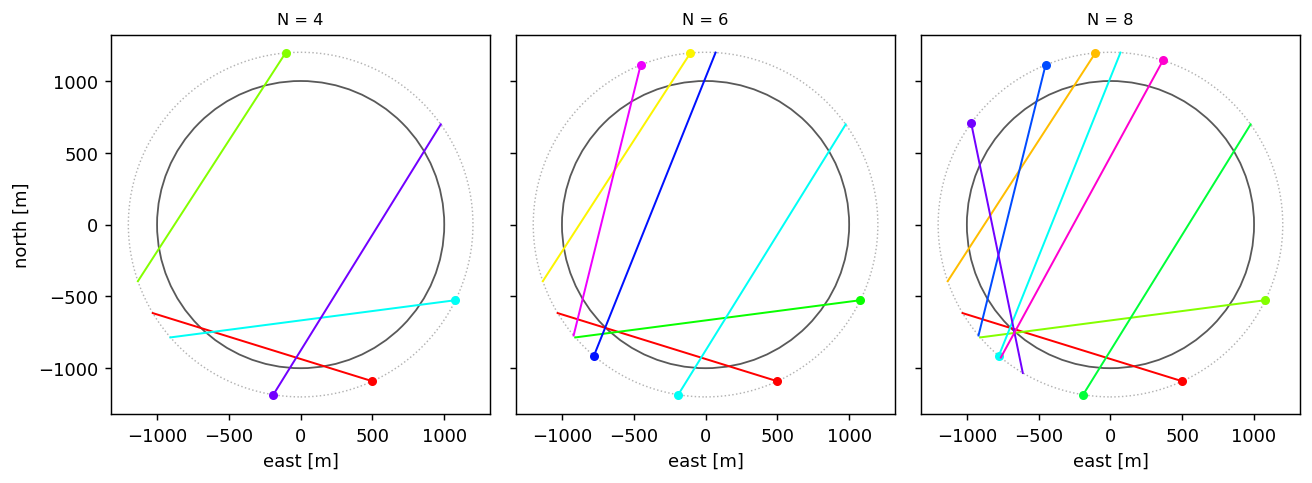

In [13]:
def enu(lat, lon):
    """Metres east/north of the disc centre."""
    qdr, dist = qdrdist(CENTRE[0], CENTRE[1], lat, lon)
    return dist * math.sin(math.radians(qdr)), dist * math.cos(math.radians(qdr))


fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.7), sharex=True, sharey=True)
for ax, n in zip(axes, RSIZES, strict=True):
    agents = sample_traffic(n, generator(children(root_seed_sequence(7), 0, 1)[0]))
    for k, a in enumerate(agents):
        x0, y0 = enu(a.state.lat, a.state.lon)
        x1, y1 = enu(*a.autopilot.goal())
        ax.plot([x0, x1], [y0, y1], lw=1.1, color=plt.cm.hsv(k / n))
        ax.plot(x0, y0, "o", ms=4, color=plt.cm.hsv(k / n))
    ax.add_patch(plt.Circle((0, 0), R_OUTER, fill=False, ls=":", lw=0.8, color="0.7"))
    ax.add_patch(plt.Circle((0, 0), R_INNER, fill=False, lw=1.0, color="0.35"))
    ax.set_aspect("equal")
    ax.set_title(f"N = {n}", fontsize=9)
    ax.set_xlabel("east [m]")
axes[0].set_ylabel("north [m]")
fig.tight_layout()

Dots are the spawn points on the outer circle (dotted); the solid circle is the measured disc. The
tracks are chords of every length and orientation, and none of them is the ring's neat diameter.

## Measuring only inside the disc

`FleetState.min_sep` accumulates over every pair, everywhere, so restricting the measurement to the
experimental area is a change to what the environment measures — which is why it is a parameter of
the environment rather than something applied to the results afterwards. `MeasurementArea` gates it:
a pair contributes only while *both* of its aircraft are inside the disc, at both ends of the step.

Two consequences worth being explicit about. First, the gated `min_sep` is also **what IPS splits
on** — the shell ladder is a sequence on this quantity — so both estimators stay on one thing;
gating only at the end would leave the splitting chasing a different event from the one reported.
Second, the run can stop as soon as every aircraft has left the disc and is heading away, because
nothing measurable can follow. That is a pure saving, checked identical run for run against a plain
900 s cap over 300 encounters, and it is on by default; pass `stop_when_departed=False` when
recording a trajectory you want to plot in full.

In [14]:
AREA = MeasurementArea(CENTRE, R_INNER)   # measured inside; released outside; stops once clear

# the ring's rules, with the longer cap a 2.4 km crossing needs
TRAFFIC_RULES = {**RULES, "t_max": 400.0, "measure_within": AREA}


def traffic_env(agents):
    return build_env(agents, navigation=GnssNavigation(), **TRAFFIC_RULES)


def traffic_encounter(n, seq):
    """One encounter: draw the traffic, then advance until terminal -- Monte Carlo, by hand."""
    geom, fwd = children(seq, 0, 2)
    agents = sample_traffic(n, generator(geom))
    env = traffic_env(agents)
    state = env.initial_state(agents)
    streams = FleetStreams(cns=CnsStreams(nav=generator(fwd)))
    while not env.is_terminal(state):
        state = env.advance(state, streams)
    return state.los, state.min_sep

## Both estimators again

The geometry is now drawn per encounter rather than fixed, so the quantity being estimated is
`P(LoS)` over the traffic distribution *and* the noise. Monte Carlo samples both by construction.
IPS has to as well, and it does it in the obvious place: `build_initial` draws one traffic sample
from the particle's own seed, which is the initial cloud the splitting then acts on. Same estimand,
same environment, two estimators.

In [15]:
rmc = {}
t0 = time.perf_counter()
for n in RSIZES:
    seqs = children(root_seed_sequence(0), 0, MC_ENCOUNTERS)
    out = Parallel(n_jobs=-1, batch_size=16)(delayed(traffic_encounter)(n, s) for s in seqs)
    rmc[n] = dict(los=np.array([o[0] for o in out]),
                  min_sep=np.array([o[1] for o in out], dtype=float))
print(f"{len(RSIZES) * MC_ENCOUNTERS} encounters in {time.perf_counter() - t0:.0f} s")

for n in RSIZES:
    k = int(rmc[n]["los"].sum())
    lo, hi = wilson_interval(k, MC_ENCOUNTERS)
    print(f"N = {n}   {k:>2}/{MC_ENCOUNTERS} lost separation   "
          f"P(LoS) = {k / MC_ENCOUNTERS:.2e}   95% Wilson [{lo:.1e}, {hi:.1e}]   "
          f"median closest approach {np.median(rmc[n]['min_sep']):.0f} m")

6000 encounters in 512 s
N = 4    0/2000 lost separation   P(LoS) = 0.00e+00   95% Wilson [1.1e-19, 1.9e-03]   median closest approach 104 m
N = 6    0/2000 lost separation   P(LoS) = 0.00e+00   95% Wilson [1.1e-19, 1.9e-03]   median closest approach 79 m
N = 8    0/2000 lost separation   P(LoS) = 0.00e+00   95% Wilson [1.1e-19, 1.9e-03]   median closest approach 70 m


Before the estimator, one traffic draw flown many times. The geometry below is **held fixed** — the
tightest of the two thousand `N = 6` encounters, so it is the closest that Monte Carlo run came to
failing — and only the GNSS noise is redrawn. Every aircraft therefore has one start and one goal,
and the spread between them is what the 10 m fix does to the flying. (The estimates themselves draw
a new geometry every encounter; this figure pins it precisely so the noise is the only thing left
moving.)

In [16]:
# Canonical Okabe-Ito. It passes the lightness, chroma and normal-vision checks; its two warnings
# -- green/pink separation under deuteranopia, and three hues under 3:1 against a light surface --
# are relieved by labelling every start and goal directly, so identity never rests on colour alone.
COLOURS = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]
N_OVERLAY = 150     # noise realisations of the one geometry
ALPHA = 0.14


def fly_fixed(agents, seq):
    """One noise realisation of a fixed traffic geometry: its tracks and its separation history."""
    env = traffic_env(agents)
    state = env.initial_state(agents)
    streams = FleetStreams(cns=CnsStreams(nav=generator(seq)))
    frames = [state]
    while not env.is_terminal(state):
        state = env.advance(state, streams)
        frames.append(state)
    tracks = [np.array([enu(f.states[k].lat, f.states[k].lon) for f in frames])
              for k in range(len(agents))]
    # the running minimum the area measured -- the very quantity IPS splits on
    running = np.array([f.min_sep for f in frames], dtype=float)
    return tracks, np.array([f.t for f in frames]), running, frames[-1].min_sep


pick = int(np.argmin(rmc[6]["min_sep"]))
geom_seq, _ = children(children(root_seed_sequence(0), 0, MC_ENCOUNTERS)[pick], 0, 2)
fixed_agents = sample_traffic(6, generator(geom_seq))              # the geometry, held
overlay = Parallel(n_jobs=-1, batch_size=8)(
    delayed(fly_fixed)(fixed_agents, s)
    for s in children(root_seed_sequence(11), 0, N_OVERLAY))       # only the noise varies
closest = np.array([r[3] for r in overlay])
print(f"tightest of {MC_ENCOUNTERS} draws at N = 6: encounter {pick}, "
      f"closest approach {rmc[6]['min_sep'][pick]:.1f} m")
print(f"that geometry over {N_OVERLAY} fresh noise draws: closest {closest.min():.1f} m, "
      f"median {np.median(closest):.1f} m, widest {closest.max():.1f} m")

tightest of 2000 draws at N = 6: encounter 738, closest approach 50.6 m
that geometry over 150 fresh noise draws: closest 53.8 m, median 62.5 m, widest 74.7 m


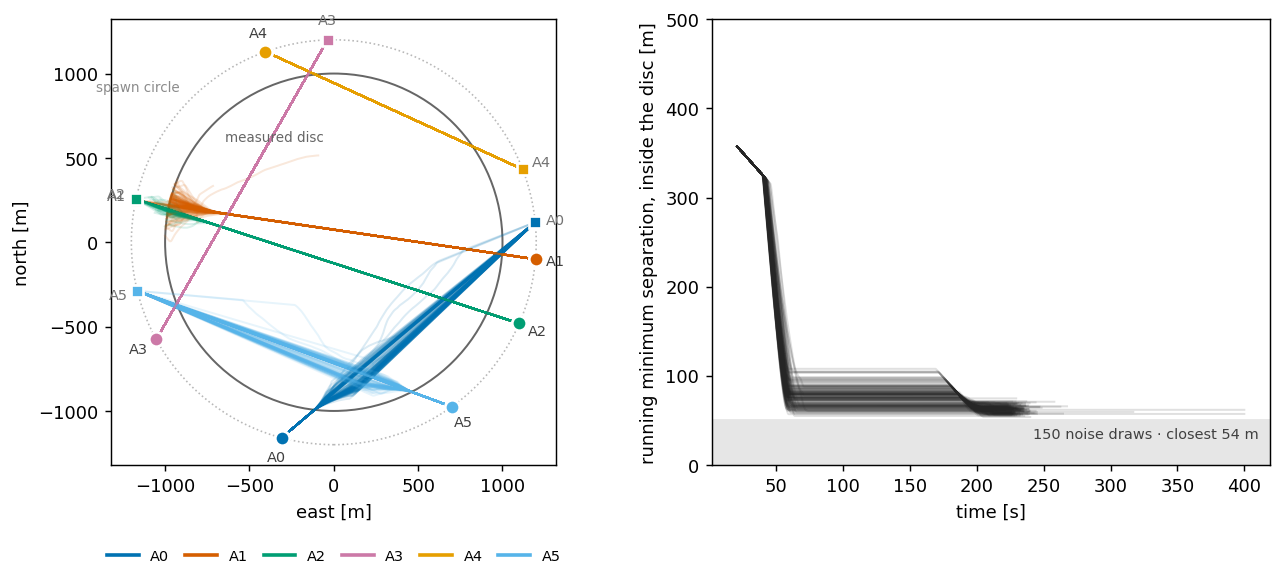

In [17]:
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10.4, 4.6),
                              gridspec_kw={"width_ratios": [1.05, 1]})

ax.add_patch(plt.Circle((0, 0), R_OUTER, fill=False, ls=":", lw=0.9, color="0.72"))
ax.add_patch(plt.Circle((0, 0), R_INNER, fill=False, lw=1.1, color="0.4"))
ax.annotate("spawn circle", (-R_OUTER / math.sqrt(2), R_OUTER / math.sqrt(2)),
            xytext=(-6, 4), textcoords="offset points", ha="right", fontsize=7.5, color="0.55")
ax.annotate("measured disc", (-R_INNER / math.sqrt(2), R_INNER / math.sqrt(2)),
            xytext=(6, -10), textcoords="offset points", fontsize=7.5, color="0.4")

for tracks, _, _, _ in overlay:                      # one faint line per aircraft per run
    for k, xy in enumerate(tracks):
        ax.plot(xy[:, 0], xy[:, 1], lw=1.1, color=COLOURS[k], alpha=ALPHA)

for k, a in enumerate(fixed_agents):
    x0, y0 = enu(a.state.lat, a.state.lon)
    x1, y1 = enu(*a.autopilot.goal())
    ax.plot(x0, y0, "o", ms=8, color=COLOURS[k], mec="white", mew=1.5, zorder=5)
    ax.plot(x1, y1, "s", ms=7, color=COLOURS[k], mec="white", mew=1.5, zorder=5)
    for (px, py), shade in (((x0, y0), "0.25"), ((x1, y1), "0.45")):   # label both ends
        r = math.hypot(px, py) or 1.0
        ax.annotate(a.state.id, (px, py), xytext=(11 * px / r, 11 * py / r),
                    textcoords="offset points", ha="center", va="center",
                    fontsize=8, color=shade, zorder=6)
    ax.plot([], [], lw=2.0, color=COLOURS[k], label=a.state.id)       # opaque legend key

ax.set_aspect("equal")
ax.set_xlabel("east [m]")
ax.set_ylabel("north [m]")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16),
          ncols=6, columnspacing=1.1, handlelength=2.2)

ax2.axhspan(0, RPZ, color="0.9", zorder=0)
for _, t, running, _ in overlay:
    ax2.plot(t, np.where(np.isfinite(running), running, np.nan), lw=1.1, color="0.15",
             alpha=ALPHA)
ax2.annotate("protected zone", (0, RPZ * 0.45), xytext=(6, 0), textcoords="offset points",
             fontsize=7.5, color="0.4")
ax2.annotate(f"{N_OVERLAY} noise draws · closest {closest.min():.0f} m", (0.98, 0.06),
             xycoords="axes fraction", ha="right", fontsize=8, color="0.25")
ax2.set_xlabel("time [s]")
ax2.set_ylabel("running minimum separation, inside the disc [m]")
ax2.set_ylim(0, 500)
fig.tight_layout()

Circles are the starts on the spawn circle, squares the goals, both labelled. Between them is one
faint line per aircraft per run, so the width of each fan is the spread the fix accuracy alone
produces on that aircraft's path — wide where an aircraft is doing the avoiding, and barely a line
where it flies through untroubled. The right panel is the same 150 runs seen as separation: each
line is that run's *running* minimum inside the disc, which only ever descends, and which is
exactly the quantity the shell ladder is a sequence on. Where those lines end is the distribution
IPS is estimating the tail of.

The two panels say the same thing from different directions. Almost all of the flying is unaffected
by the noise; the spread concentrates in the few aircraft that manoeuvre, in the seconds around the
crossing, and it is there that the difference between clearing by 60 m and losing separation is
decided.

The ladders are built by the same rule as before, with one change: the run-in step is a metre rather
than half a metre. Most drawn geometries never come close, so these ladders start far higher — the
first shell is around 100 m at `N = 4` — and a half-metre run-in below that spends shells where
three quarters of the particles survive, which is effort bought and not used.

In [18]:
RLADDERS = {n: build_ladder(rmc[n]["min_sep"][np.isfinite(rmc[n]["min_sep"])], step=1.0)
            for n in RSIZES}
for n in RSIZES:
    print(f"N = {n}  ({len(RLADDERS[n])} shells)  " + "  ".join(f"{d:g}" for d in RLADDERS[n]))

N = 4  (15 shells)  104.31  77.95  69.22  64.13  60.95  58.7  57.7  56.7  55.7  54.7  53.7  52.7  51.7  50.7  50
N = 6  (13 shells)  78.58  68.1  63  60.14  57.99  56.67  55.67  54.67  53.67  52.67  51.67  50.67  50
N = 8  (11 shells)  69.61  63.27  59.95  57.98  56.22  54.98  53.98  52.98  51.98  50.98  50


In [19]:
R_PARTICLES = 600   # per shell


def traffic_cloud(n):
    """Each particle draws its own traffic -- the distribution Monte Carlo integrates over."""
    def build_initial(seq):
        agents = sample_traffic(n, generator(seq))
        env = traffic_env(agents)
        return Particle(env=env, state=env.initial_state(agents))
    return build_initial


rips = {}
for n in RSIZES:
    t0 = time.perf_counter()
    rips[n] = estimate_rare_prob(traffic_cloud(n), RLADDERS[n],
                                 n_particles=R_PARTICLES, reps=REPS, seed=1, n_jobs=-1)
    est = rips[n]
    print(f"N = {n}   P(LoS) = {est.prob:.2e}   95% CI [{est.ci[0]:.1e}, {est.ci[1]:.1e}]   "
          f"collapsed {est.n_collapsed}/{REPS}   ({time.perf_counter() - t0:.0f} s)")

N = 4   P(LoS) = 3.90e-05   95% CI [2.1e-05, 5.5e-05]   collapsed 0/6   (502 s)


N = 6   P(LoS) = 1.17e-04   95% CI [4.9e-05, 1.7e-04]   collapsed 0/6   (821 s)


N = 8   P(LoS) = 3.59e-04   95% CI [2.0e-04, 5.0e-04]   collapsed 0/6   (1208 s)


In [20]:
print(f"{'N':>3}  {'MC P(LoS)':>22}  {'MC 95% CI':>22}   {'IPS P(LoS)':>11}  {'IPS 95% CI':>22}")
for n in RSIZES:
    k = int(rmc[n]["los"].sum())
    p_mc = "no events" if k == 0 else f"{k / MC_ENCOUNTERS:.2e} ({k} event{'s' * (k > 1)})"
    est = rips[n]
    print(f"{n:>3}  {p_mc:>22}  {interval(*wilson_interval(k, MC_ENCOUNTERS))}   "
          f"{est.prob:>11.2e}  {interval(*est.ci)}")

  N               MC P(LoS)               MC 95% CI    IPS P(LoS)              IPS 95% CI
  4               no events  [0.00e+00, 1.92e-03]      3.90e-05  [2.09e-05, 5.48e-05]
  6               no events  [0.00e+00, 1.92e-03]      1.17e-04  [4.92e-05, 1.68e-04]
  8               no events  [0.00e+00, 1.92e-03]      3.59e-04  [2.03e-04, 4.98e-04]


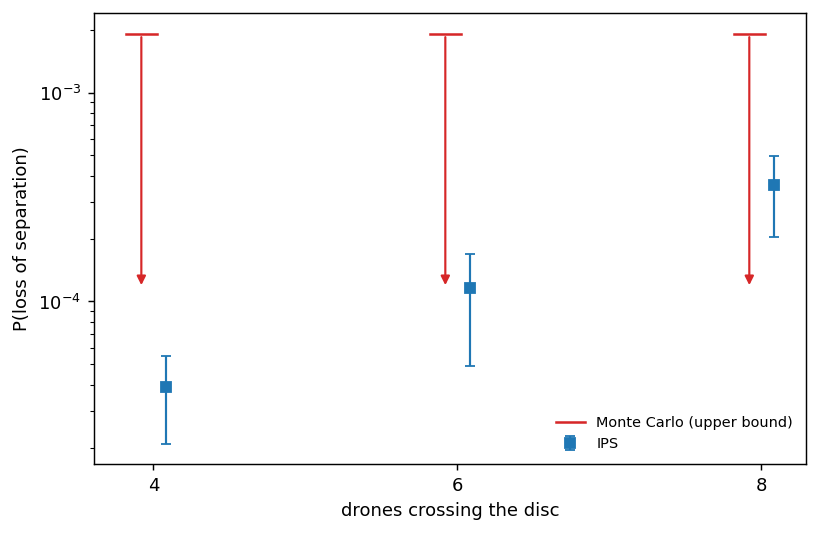

In [21]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))
xr = np.array(RSIZES, dtype=float)

rmc_p = np.array([rmc[n]["los"].sum() / MC_ENCOUNTERS for n in RSIZES])
rmc_ci = np.array([wilson_interval(int(rmc[n]["los"].sum()), MC_ENCOUNTERS) for n in RSIZES])
rseen = rmc_p > 0
if rseen.any():
    ax.errorbar(xr[rseen] - 0.08, rmc_p[rseen],
                yerr=[rmc_p[rseen] - rmc_ci[rseen, 0], rmc_ci[rseen, 1] - rmc_p[rseen]],
                fmt="o", ms=5, capsize=3, lw=1.2, color="#d62728", label="Monte Carlo")
for xi, hi in zip(xr[~rseen] - 0.08, rmc_ci[~rseen, 1], strict=True):
    ax.annotate("", (xi, hi * 0.06), (xi, hi),
                arrowprops=dict(arrowstyle="-|>", lw=1.2, color="#d62728"))
    ax.plot([xi - 0.1, xi + 0.1], [hi, hi], lw=1.4, color="#d62728")
if not rseen.any():
    ax.plot([], [], color="#d62728", lw=1.4, label="Monte Carlo (upper bound)")

rips_p = np.array([rips[n].prob for n in RSIZES])
rips_ci = np.array([rips[n].ci for n in RSIZES])
ax.errorbar(xr + 0.08, rips_p, yerr=[rips_p - rips_ci[:, 0], rips_ci[:, 1] - rips_p],
            fmt="s", ms=5, capsize=3, lw=1.2, color="#1f77b4", label="IPS")

ax.set_yscale("log")
ax.set_xticks(list(RSIZES))
ax.set_xlabel("drones crossing the disc")
ax.set_ylabel("P(loss of separation)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

The shape of the result is the same as the ring's, at a different scale: risk rises steeply with the
number of aircraft sharing the area, and Monte Carlo cannot resolve any of it at two thousand
encounters. What random traffic adds is that the number now belongs to a *distribution* of
geometries rather than to one arrangement, which is the form a density-based safety argument needs.

It is worth being clear about what is not being claimed. This is a fixed count of aircraft crossing
a disc, not the paper's steady-state density: aircraft all start together and are not replaced as
they leave, so `N` here is an instantaneous count, and converting it to the paper's AC/NM² would
mean spawning on an interval instead.

## Reading the numbers honestly

Both parts are trial-scale runs, and the settings are visible above rather than buried: `dt = 0.5 s`,
2000 Monte Carlo encounters per cell, 600–2500 particles, 6 replications. What that buys and what it
does not:

- **The confidence intervals are wide** — six replications is few. Raising `REPS` narrows them at
  proportional cost, and `n_jobs=-1` already fills the machine whatever `REPS` is.
- **The interval covers replication scatter, not the choice of ladder.** That choice moves the
  answer too, and by a measurable amount: at `N = 4` random traffic, holding the particle count and
  replications fixed and changing only the run-in step from 1 m to 0.5 m moved the estimate from
  `3.90e-05` to `3.07e-05` — about 27%, with the two intervals overlapping heavily. Read a
  trial-scale rare-event number as good to a factor rather than to its last digit.
- **`dt = 0.5 s` carries a discretisation bias.** The minimum separation is measured over each
  segment rather than at its endpoints, so the bias is small, but it is not zero; production runs
  use `dt = 0.2 s`.
- **The ladder is scenario-specific.** Each was built from *that* fleet's own Monte Carlo record,
  and a ladder that works at one size need not work at another — the shells are placed by the
  distribution precisely because the distribution moves.
- **The two parts estimate different things.** Part 1 pins the geometry, so it is
  `P(LoS | this encounter)` over the CNS noise alone. Part 2 draws the geometry per encounter, so it
  is a probability over the traffic distribution as well — but over a fixed *count* of aircraft
  crossing a disc, not the paper's steady-state density, and so still not a rate per flight hour.
- **Horizontal only.** The paper this traffic rule comes from separates aircraft vertically by
  layer and studies vertical manoeuvres; everything here is in the plane.

To turn the trial into a production estimate: raise the particle counts for headroom against
collapse, raise `REPS` for the interval, set `DT = 0.2`, and leave everything else exactly as it is.